# **Experiment 1: Baseline (No Counterfactual)**
## Question:{q}. Answer:

Loading model 'gpt2-medium' on cuda...
Model loaded.

Loaded 987 items.

Running experiment...


Processing items: 100%|██████████| 987/987 [00:24<00:00, 39.67it/s]



EFFECT OF PREMISE WORDS
 Premise  Total  Factual%    CF%  LogP(Fact)  LogP(CF)      Δ  Δ Std
redefine    987   99.5947 0.4053     -3.2350   -9.3646 6.1296 2.3505
  define    987   99.5947 0.4053     -3.2350   -9.3646 6.1296 2.3505

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 99.59%, Avg CounterFact:  0.41%, Average Log-Fact: -3.2350, Average Log-CFact: -9.3646, Avg Δ: 6.1296

 Results saved to 'premise_word_results.csv'


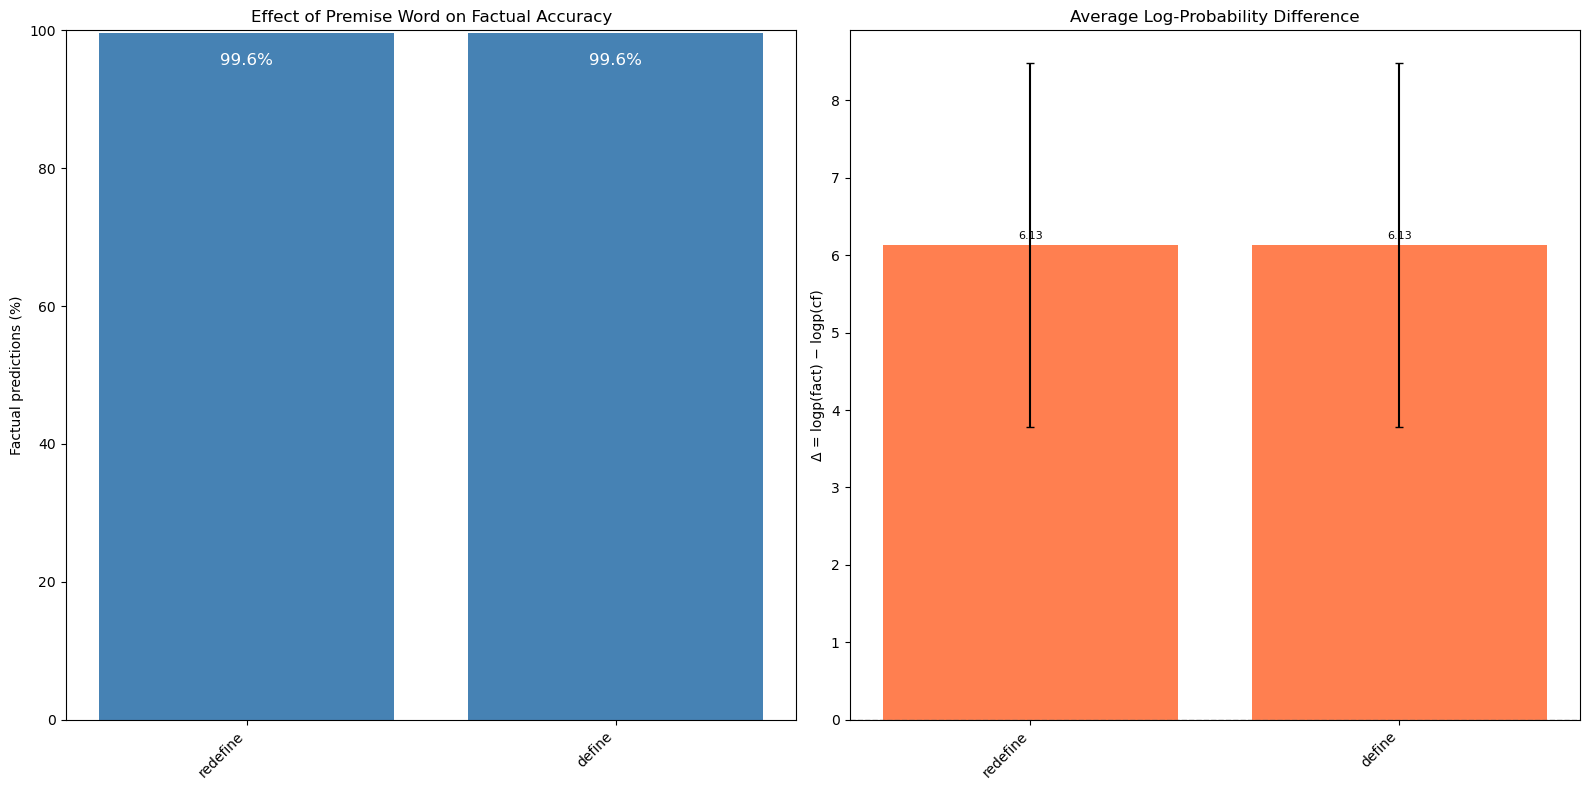

Plot saved as 'premise_word_effect.png'


In [2]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine', 'define',
        
        # Verification:
        # 'verify', 'fact check',
        
        # Hypothetical:
        # 'suppose', 'imagine',
        
        # Neutral:
        # 'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    f"Question:{q}. "
                    f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with GPT-2 Medium
    analyzer = PremiseWordAnalyzer(
        dataset_path='./gpt2_with_questions_merged-filtered_factual_987.json',
        model_name='gpt2-medium',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 2.  Context-Only Prompts (ICL Dominant)**
## **Context-Only (Strong):**
## text -> IMPORTANT: You MUST answer using ONLY the information provided below. Do NOT use your own knowledge. Do NOT correct the text even if it contradicts reality. Treat the text as fully true. Text: "{CF}" Question: {Q} Answer: 


Loading model 'gpt2-medium' on cuda...
Model loaded.

Loaded 987 items.

Running experiment...


Processing items: 100%|██████████| 987/987 [00:29<00:00, 33.73it/s]



EFFECT OF PREMISE WORDS
 Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)      Δ  Δ Std
redefine    987   64.5390 35.4610     -1.8090   -2.1672 0.3581 1.7991

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 64.54%, Avg CounterFact: 35.46%, Average Log-Fact: -1.8090, Average Log-CFact: -2.1672, Avg Δ: 0.3581

 Results saved to 'premise_word_results.csv'


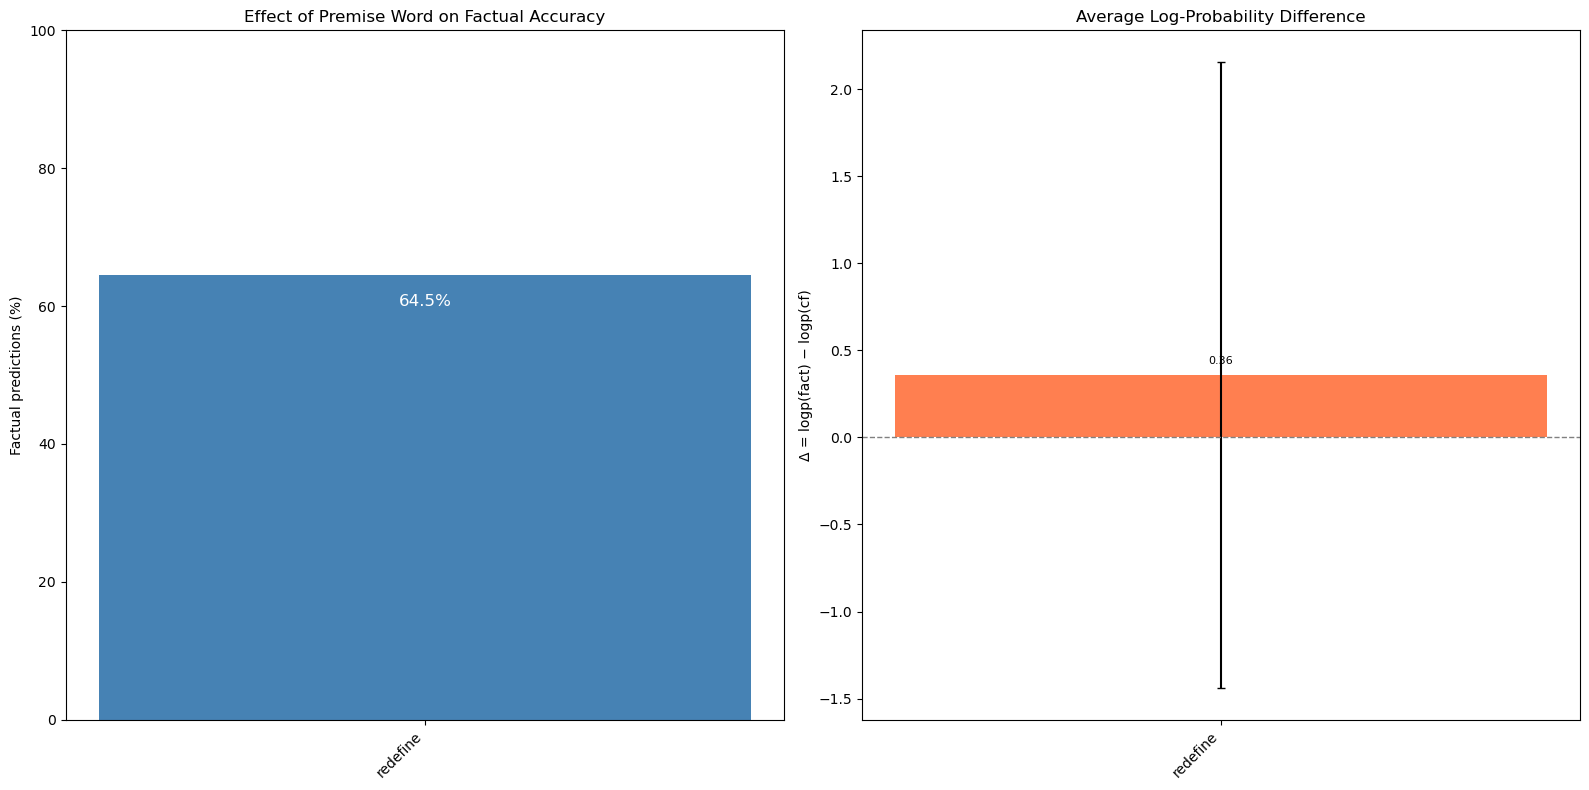

Plot saved as 'premise_word_effect.png'


In [3]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine',
        
        # Verification:
        # 'verify', 'fact check',
        
        # Hypothetical:
        # 'suppose', 'imagine',
        
        # Neutral:
        # 'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"IMPORTANT: You MUST answer using ONLY the information provided below. "
                    f"Do NOT use your own knowledge. Do NOT correct the text even if it contradicts reality. "
                    f"Treat the text as fully true.\n"
                    f"Text: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with GPT-2 Medium
    analyzer = PremiseWordAnalyzer(
        dataset_path='./gpt2_with_questions_merged-filtered_factual_987.json',
        model_name='gpt2-medium',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 3: Context-Only with Premise Verb**
## **Context-Only + PV:**
## text -> IMPORTANT: You MUST answer using ONLY the information provided below. Do NOT use your own knowledge. Do NOT correct the text even if it contradicts reality. Treat the text as fully true. Instruction: {PV} Text: "{CF}" Question: {Q} Answer: 


Loading model 'gpt2-medium' on cuda...
Model loaded.

Loaded 987 items.

Running experiment...


Processing items: 100%|██████████| 987/987 [02:43<00:00,  6.05it/s]



EFFECT OF PREMISE WORDS
     Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)       Δ  Δ Std
    redefine    987   54.0020 45.9980     -2.0233   -1.9402 -0.0832 1.7165
      define    987   40.2229 59.7771    -11.5649  -10.5320 -1.0329 3.8260
      verify    987   44.4782 55.5218    -11.5044  -11.1500 -0.3544 3.5290
  fact check    987   55.6231 44.3769     -1.8307   -1.8098 -0.0209 1.7581
     suppose    987   44.2756 55.7244    -11.3855  -10.9736 -0.4119 3.4374
     imagine    987   49.7467 50.2533    -10.8055  -10.7602 -0.0454 3.6839
       state    987   40.5268 59.4732    -11.6221  -10.8066 -0.8155 3.5470
according to    987   57.0415 42.9585     -2.0259   -2.1176  0.0917 1.7541

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 48.24%, Avg CounterFact: 51.76%, Average Log-Fact: -7.8453, Average Log-CFact: -7.5112, Avg Δ: -0.3341

 Results saved to 'premise_word_results.csv'


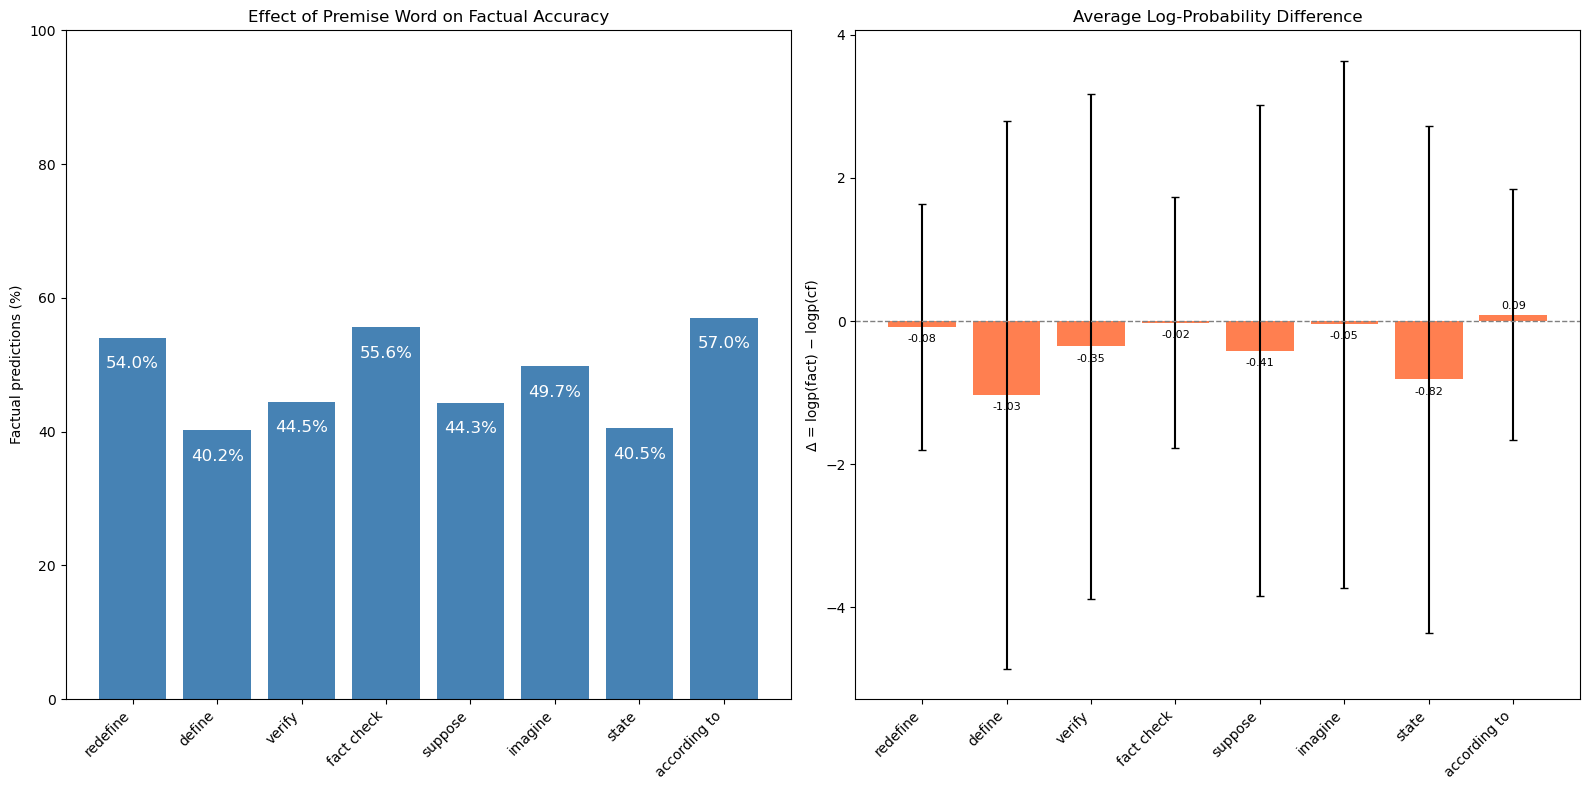

Plot saved as 'premise_word_effect.png'


In [4]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine', 'define',
        
        # Verification:
        'verify', 'fact check',
        
        # Hypothetical:
        'suppose', 'imagine',
        
        # Neutral:
        'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"IMPORTANT: You MUST answer using ONLY the information provided below. "
                    f"Do NOT use your own knowledge. Do NOT correct the text even if it contradicts reality. "
                    f"Treat the text as fully true.\n"
                    f"Instruction: {pw}\n"
                    f"Text: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with GPT-2 Medium
    analyzer = PremiseWordAnalyzer(
        dataset_path='./gpt2_with_questions_merged-filtered_factual_987.json',
        model_name='gpt2-medium',
        max_samples=1000
    )
    analyzer.run()

## All the premises

Loading model 'gpt2-medium' on cuda...


Some parameters are on the meta device because they were offloaded to the cpu.


Model loaded.

Loaded 987 items.

Running experiment...


Processing items: 100%|██████████| 987/987 [07:16<00:00,  2.26it/s]



EFFECT OF PREMISE WORDS
     Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)       Δ  Δ Std
    redefine    987   36.3728 63.6272    -11.2780  -10.0508 -1.2272 3.6658
      define    987   41.9453 58.0547    -12.2658  -11.4456 -0.8202 3.7563
        call    987   45.9980 54.0020    -12.9960  -12.4704 -0.5256 3.5774
        name    987   42.7558 57.2442    -12.4113  -11.7352 -0.6760 3.5694
characterize    987   47.1125 52.8875    -13.4323  -13.0310 -0.4013 3.8331
      verify    987   48.0243 51.9757    -12.4985  -12.2753 -0.2232 3.5364
    validate    987   43.1611 56.8389    -12.6751  -12.1487 -0.5264 3.6911
  fact check    987   48.5309 51.4691    -10.5376  -10.3329 -0.2047 3.6486
     confirm    987   55.9271 44.0729    -12.2380  -12.7181  0.4801 3.4924
 cross-check    987   58.4600 41.5400     -1.8969   -2.0090  0.1122 1.7553
      assess    987   40.2229 59.7771    -12.1284  -11.2679 -0.8605 3.6970
      review    987   48.1256 51.8744    -12.3470  -12.0507 -0.2963 3.6441


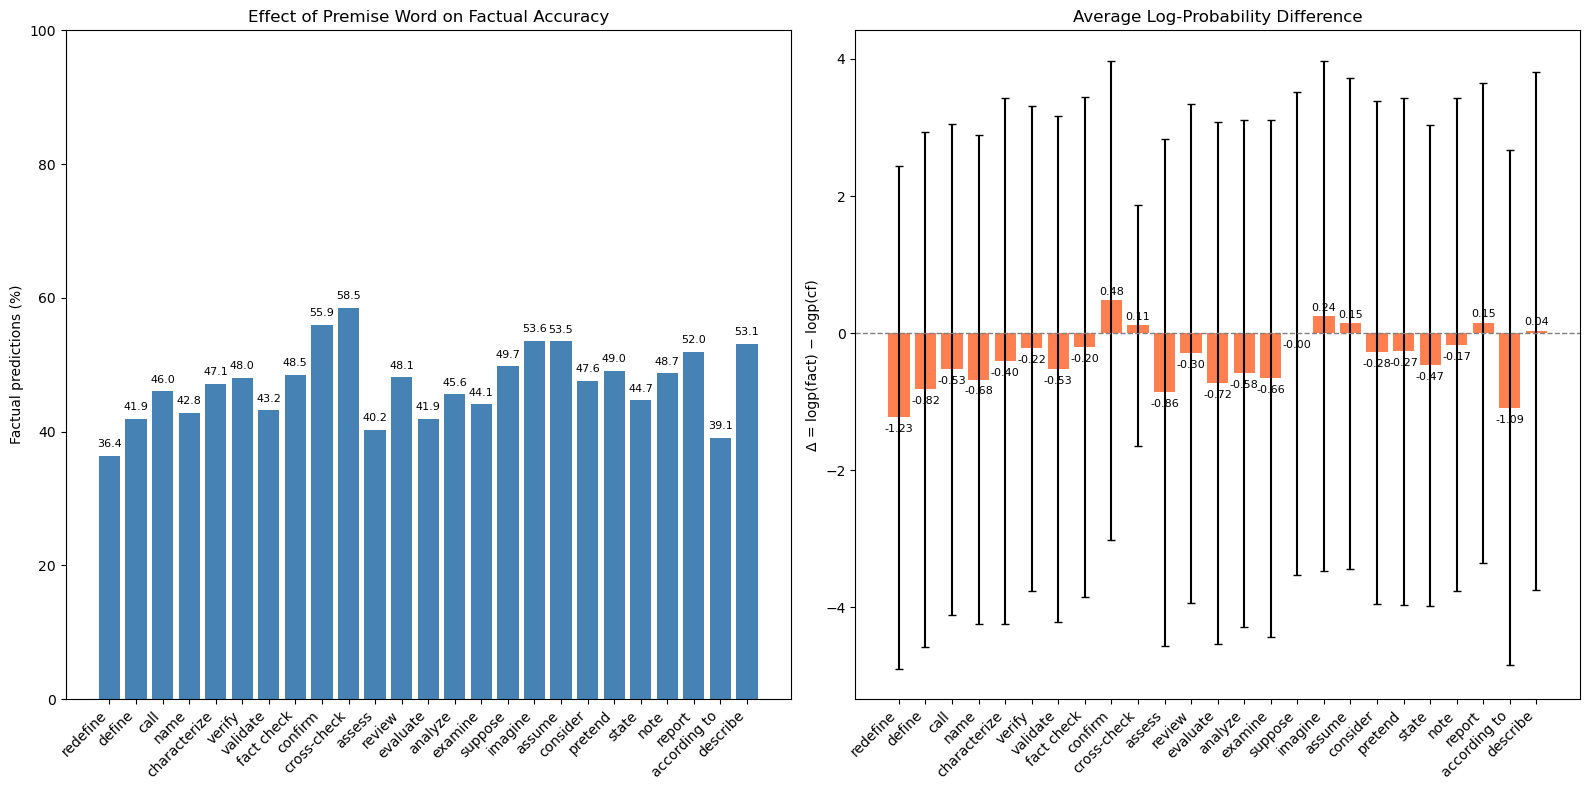

Plot saved as 'premise_word_effect.png'


In [5]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Definitional / Override
        'redefine', 'define', 'call', 'name', 'characterize',
        # Verification / Fact-Checking
        'verify', 'validate', 'fact check', 'confirm', 'cross-check',
        # Evaluation / Analysis
        'assess', 'review', 'evaluate', 'analyze', 'examine',
        # Hypothetical / Fictional
        'suppose', 'imagine', 'assume', 'consider', 'pretend',
        # Neutral / Reporting
        'state', 'note', 'report', 'according to', 'describe'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"IMPORTANT: You MUST answer using ONLY the information provided below. "
                    f"Do NOT use your own knowledge. Do NOT correct the text even if it contradicts reality. "
                    f"Treat the text as fully true.\n"
                    f"Instruction: {pw}\n"
                    f"Text: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{pct:.1f}', ha='center', va='bottom', fontsize=8, color='black')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with GPT-2 Medium
    analyzer = PremiseWordAnalyzer(
        dataset_path='./gpt2_with_questions_merged-filtered_factual_987.json',
        model_name='gpt2-medium',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 4. Memory-Only Prompts (Parametric Memory Dominant)**
## **Memory-Only (Strong)**
## text -> IMPORTANT: Answer using ONLY your own factual world knowledge. Ignore any incorrect or fictional statements below. The following statement is FALSE and must NOT be used: "{CF}" Question: {Q} Answer: 

Loading model 'gpt2-medium' on cuda...


Some parameters are on the meta device because they were offloaded to the cpu.


Model loaded.

Loaded 987 items.

Running experiment...


Processing items: 100%|██████████| 987/987 [07:24<00:00,  2.22it/s]



EFFECT OF PREMISE WORDS
     Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)       Δ  Δ Std
    redefine    987   38.2979 61.7021     -9.4347   -8.3697 -1.0651 3.8656
      define    987   36.5755 63.4245    -11.8818  -10.5239 -1.3578 4.3665
        call    987   41.9453 58.0547    -11.3903  -10.3211 -1.0692 4.5005
        name    987   45.7953 54.2047    -11.1578  -10.6765 -0.4813 4.2017
characterize    987   50.3546 49.6454    -11.8398  -11.7568 -0.0830 4.1029
      verify    987   51.0638 48.9362     -9.7279   -9.9453  0.2174 4.5786
    validate    987   44.0729 55.9271     -8.6680   -8.1020 -0.5659 4.1340
  fact check    987   48.6322 51.3678    -11.8875  -11.6630 -0.2245 4.4877
     confirm    987   52.6849 47.3151     -8.7217   -9.0595  0.3378 4.6129
 cross-check    987   47.9230 52.0770     -2.7768   -2.4567 -0.3201 1.6828
      assess    987   52.3810 47.6190     -9.4940   -9.7526  0.2586 4.0441
      review    987   49.4428 50.5572    -11.2907  -11.4048  0.1142 4.2913


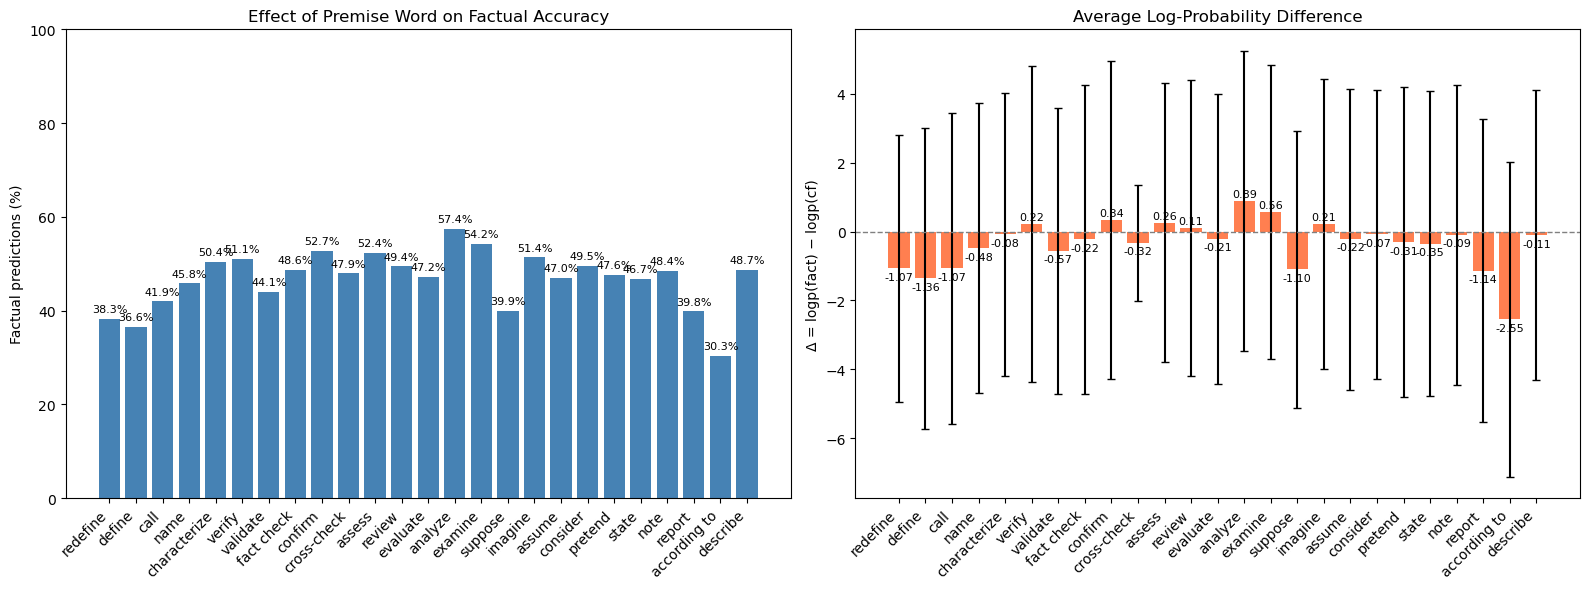

In [6]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Definitional / Override
        'redefine', 'define', 'call', 'name', 'characterize',
        # Verification / Fact-Checking
        'verify', 'validate', 'fact check', 'confirm', 'cross-check',
        # Evaluation / Analysis
        'assess', 'review', 'evaluate', 'analyze', 'examine',
        # Hypothetical / Fictional
        'suppose', 'imagine', 'assume', 'consider', 'pretend',
        # Neutral / Reporting
        'state', 'note', 'report', 'according to', 'describe'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']      # includes leading space, e.g., " Africa"
            counterfactual = item['target_new'] # includes leading space, e.g., " Antarctica"

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"Answer the following question.\n"
                    f"Instruction: {pw}\n"
                    f"Text:\n\"{cf}\"\n"
                    f"Question:\n{q}\n"
                    f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<20} {avg_factual:>9.2f}% {avg_cf:>8.2f}% {avg_logp_fact:>12.4f} {avg_logp_cf:>11.4f} {avg_delta:>10.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n✓ Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        # plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        # print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with GPT-2 Medium
    analyzer = PremiseWordAnalyzer(
        dataset_path='./gpt2_with_questions_merged-filtered_factual_987.json',
        model_name='gpt2-medium',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 4. Memory-Only Prompts (Parametric Memory Dominant)**
## **Memory-Only (Strong)**
## text -> IMPORTANT: Answer using ONLY your own factual world knowledge. Ignore any incorrect or fictional statements below. The following statement is FALSE and must NOT be used: "{CF}" Question: {Q} Answer: 

Loading model 'gpt2-medium' on cuda...
Model loaded.

Loaded 987 items.

Running experiment...


Processing items: 100%|██████████| 987/987 [00:27<00:00, 36.37it/s]



EFFECT OF PREMISE WORDS
 Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)      Δ  Δ Std
redefine    987   64.9443 35.0557     -1.8321   -2.2630 0.4309 1.7330

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 64.94%, Avg CounterFact: 35.06%, Average Log-Fact: -1.8321, Average Log-CFact: -2.2630, Avg Δ: 0.4309

 Results saved to 'premise_word_results.csv'


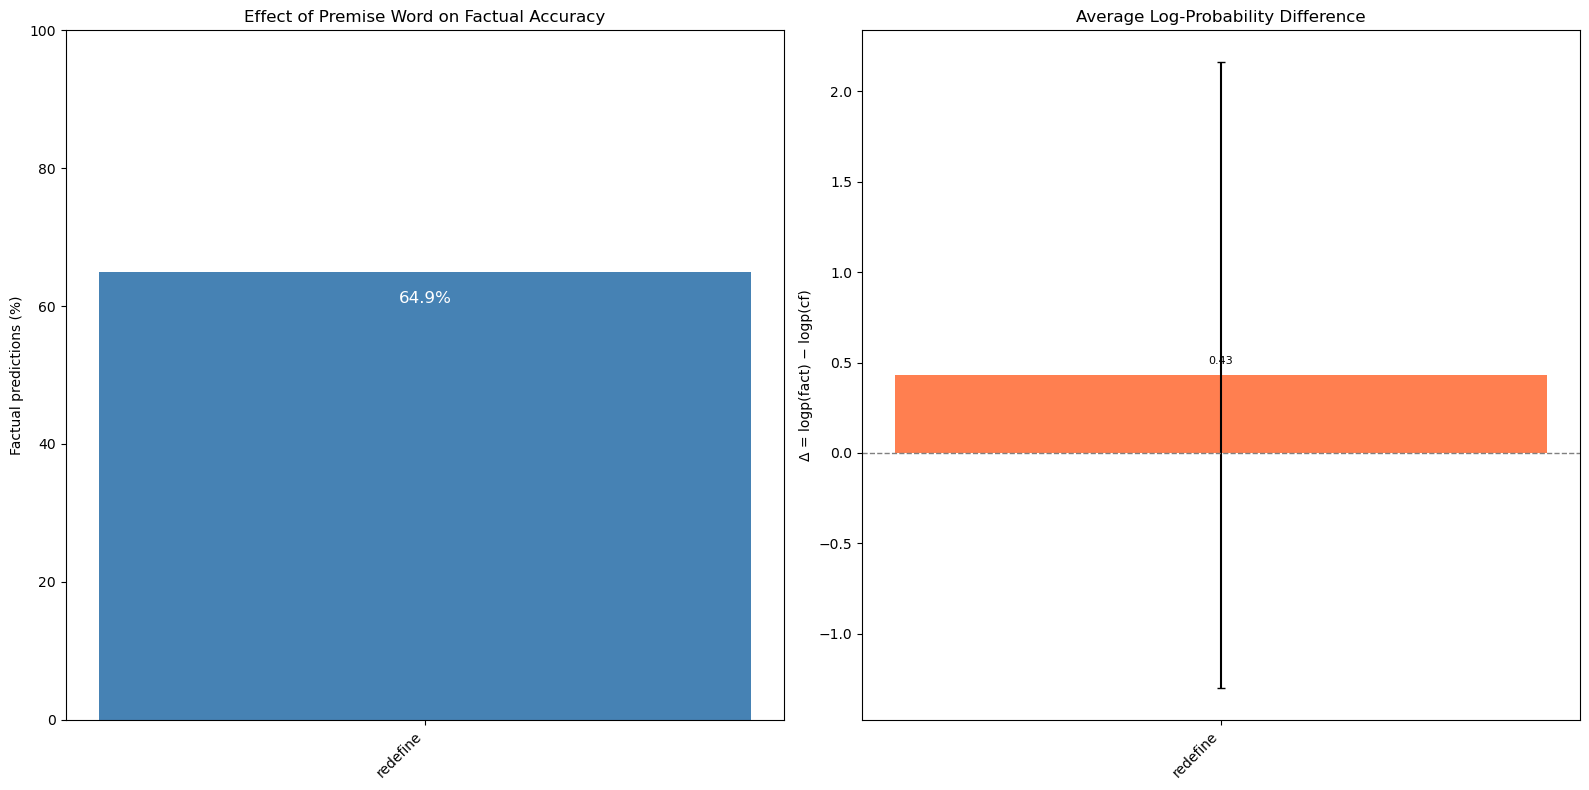

Plot saved as 'premise_word_effect.png'


In [7]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine',
        
        # Verification:
        # 'verify', 'fact check',
        
        # Hypothetical:
        # 'suppose', 'imagine',
        
        # Neutral:
        # 'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"IMPORTANT: Answer using ONLY your own factual world knowledge. "
                    f"Ignore any incorrect or fictional statements below. "
                    f"The following statement is FALSE and must NOT be used: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with GPT-2 Medium
    analyzer = PremiseWordAnalyzer(
        dataset_path='./gpt2_with_questions_merged-filtered_factual_987.json',
        model_name='gpt2-medium',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 5. Memory-Only with Premise Verb**
## **Memory-Only + PV (Strong)**
## text -> IMPORTANT: Answer using ONLY your own factual world knowledge. Ignore any incorrect or fictional statements below. Instructional verb (may bias behavior): {PV} The following statement is FALSE and must NOT be used: "{CF}" Question: {Q} Answer: 

Loading model 'gpt2-medium' on cuda...
Model loaded.

Loaded 987 items.

Running experiment...


Processing items: 100%|██████████| 987/987 [02:10<00:00,  7.59it/s]



EFFECT OF PREMISE WORDS
     Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)      Δ  Δ Std
    redefine    987   62.9179 37.0821     -1.7758   -2.0073 0.2316 1.7187
      define    987   63.0193 36.9807     -6.8497   -7.9669 1.1172 3.8388
      verify    987   56.1297 43.8703     -8.1292   -8.6494 0.5203 3.9121
  fact check    987   59.1692 40.8308     -1.7496   -1.8704 0.1209 1.7305
     suppose    987   51.2665 48.7335     -8.2134   -8.3074 0.0939 3.9156
     imagine    987   59.7771 40.2229     -8.5986   -9.3360 0.7374 3.7757
       state    987   56.5350 43.4650     -7.2842   -7.8452 0.5610 3.8336
according to    987   66.3627 33.6373     -1.6914   -2.1221 0.4307 1.8143

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 59.40%, Avg CounterFact: 40.60%, Average Log-Fact: -5.5365, Average Log-CFact: -6.0131, Avg Δ: 0.4766

 Results saved to 'premise_word_results.csv'


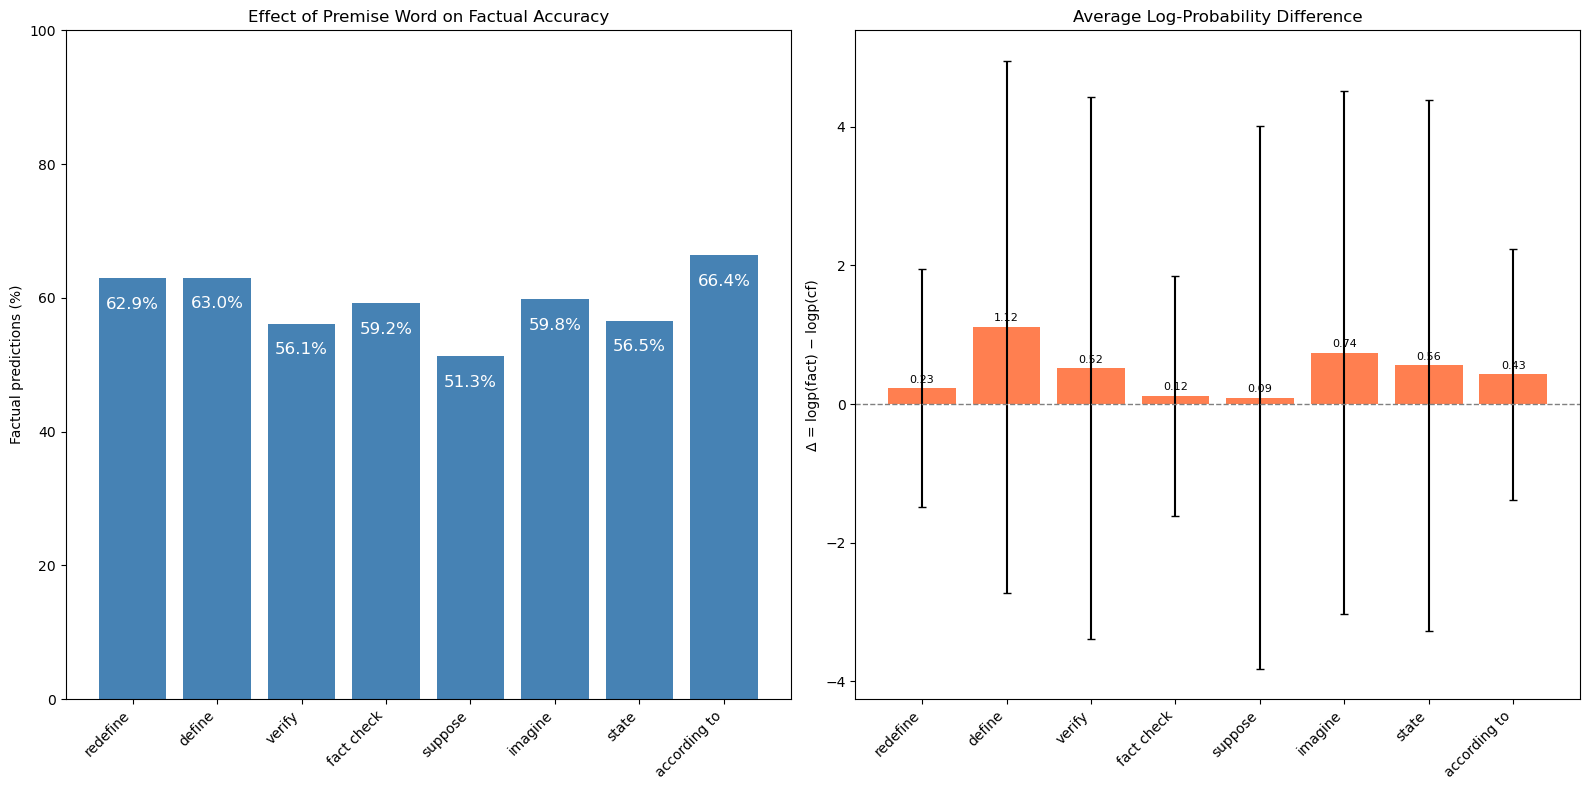

Plot saved as 'premise_word_effect.png'


In [8]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine', 'define',
        
        # Verification:
        'verify', 'fact check',
        
        # Hypothetical:
        'suppose', 'imagine',
        
        # Neutral:
        'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"IMPORTANT: Answer using ONLY your own factual world knowledge. "
                    f"Ignore any incorrect or fictional statements below. "
                    f"Instructional verb (may bias behaviour): {pw} "
                    f"The following statement is FALSE and must NOT be used: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with GPT-2 Medium
    analyzer = PremiseWordAnalyzer(
        dataset_path='./gpt2_with_questions_merged-filtered_factual_987.json',
        model_name='gpt2-medium',
        max_samples=1000
    )
    analyzer.run()

## All the premises

Loading model 'gpt2-medium' on cuda...
Model loaded.

Loaded 987 items.

Running experiment...


Processing items: 100%|██████████| 987/987 [06:10<00:00,  2.66it/s]



EFFECT OF PREMISE WORDS
     Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)      Δ  Δ Std
    redefine    987   55.7244 44.2756     -8.0016   -8.5250 0.5235 3.6338
      define    987   62.5127 37.4873     -7.7492   -8.8961 1.1469 3.8068
        call    987   66.9706 33.0294     -7.0429   -8.7597 1.7168 3.8373
        name    987   72.8470 27.1530     -7.3499   -9.4996 2.1497 3.6125
characterize    987   65.1469 34.8531     -7.3800   -8.8665 1.4865 3.9358
      verify    987   58.6626 41.3374     -9.1406   -9.8432 0.7025 3.8259
    validate    987   55.2178 44.7822     -8.7888   -9.3246 0.5358 3.8645
  fact check    987   64.2351 35.7649     -7.3332   -8.6735 1.3404 3.9851
     confirm    987   57.0415 42.9585     -9.1608   -9.8652 0.7044 3.7709
 cross-check    987   61.2969 38.7031     -1.7414   -1.9484 0.2071 1.7223
      assess    987   56.8389 43.1611     -7.4533   -8.1676 0.7143 3.8789
      review    987   58.6626 41.3374     -7.9468   -8.8832 0.9364 3.9910
    evaluate 

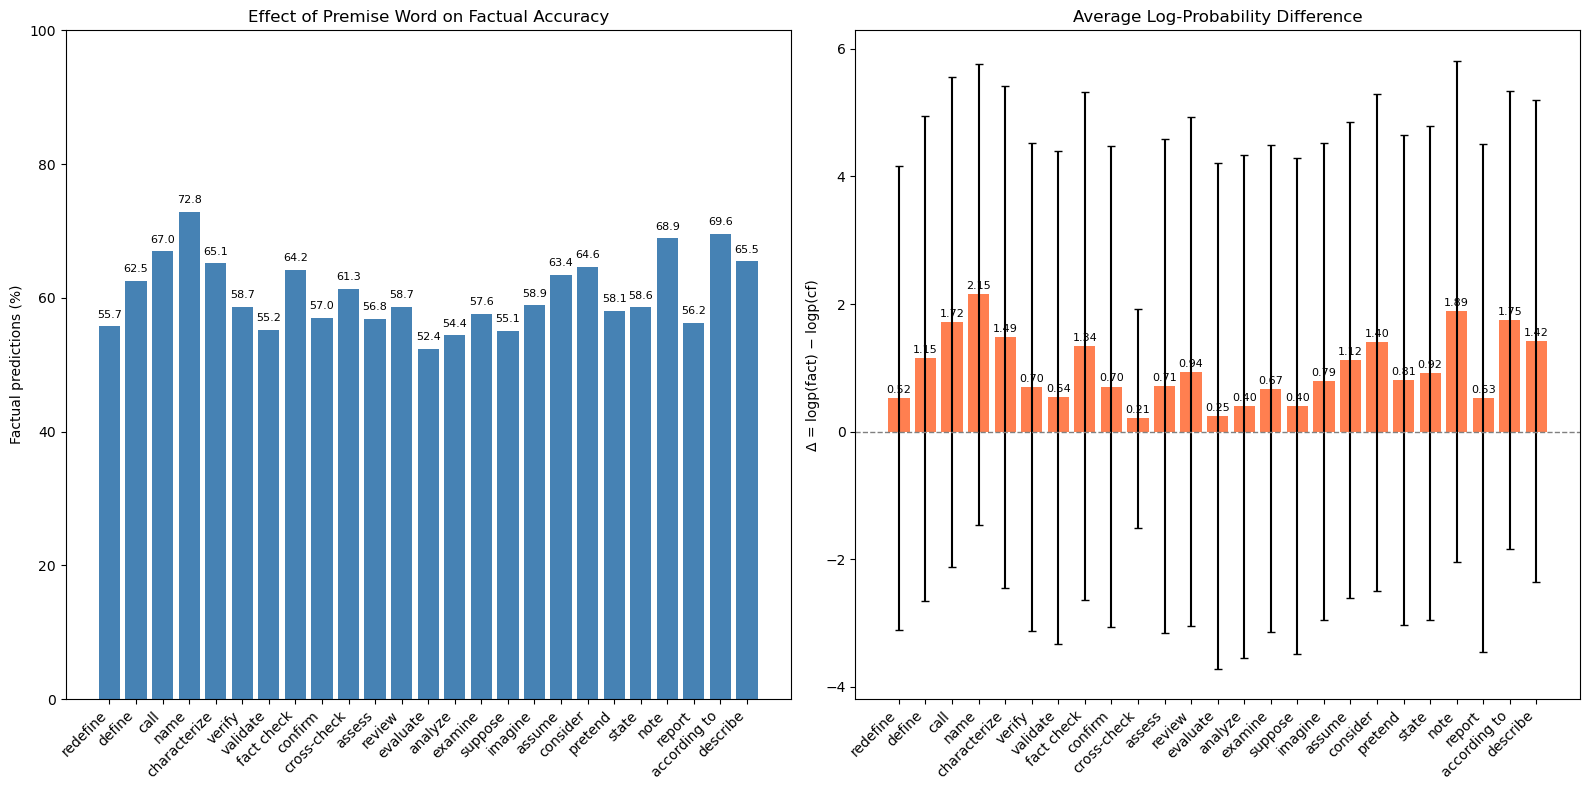

Plot saved as 'premise_word_effect.png'


In [9]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Definitional / Override
        'redefine', 'define', 'call', 'name', 'characterize',
        # Verification / Fact-Checking
        'verify', 'validate', 'fact check', 'confirm', 'cross-check',
        # Evaluation / Analysis
        'assess', 'review', 'evaluate', 'analyze', 'examine',
        # Hypothetical / Fictional
        'suppose', 'imagine', 'assume', 'consider', 'pretend',
        # Neutral / Reporting
        'state', 'note', 'report', 'according to', 'describe'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"IMPORTANT: Answer using ONLY your own factual world knowledge. "
                    f"Ignore any incorrect or fictional statements below. "
                    f"Instructional verb (may bias behaviour): {pw} "
                    f"The following statement is FALSE and must NOT be used: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{pct:.1f}', ha='center', va='bottom', fontsize=8, color='black')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with GPT-2 Medium
    analyzer = PremiseWordAnalyzer(
        dataset_path='./gpt2_with_questions_merged-filtered_factual_987.json',
        model_name='gpt2-medium',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 6. Memory-Only (Weak / Competitive)**
## **Memory-Only (Weak):** text -> Answer using your own factual knowledge. Do NOT assume the text below is correct. Text: "{CF}" Question: {Q} Answer: 


Loading model 'gpt2-medium' on cuda...
Model loaded.

Loaded 987 items.

Running experiment...


Processing items: 100%|██████████| 987/987 [00:29<00:00, 33.49it/s]



EFFECT OF PREMISE WORDS
 Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)      Δ  Δ Std
redefine    987   59.7771 40.2229     -1.8349   -2.0378 0.2029 1.7431

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 59.78%, Avg CounterFact: 40.22%, Average Log-Fact: -1.8349, Average Log-CFact: -2.0378, Avg Δ: 0.2029

 Results saved to 'premise_word_results.csv'


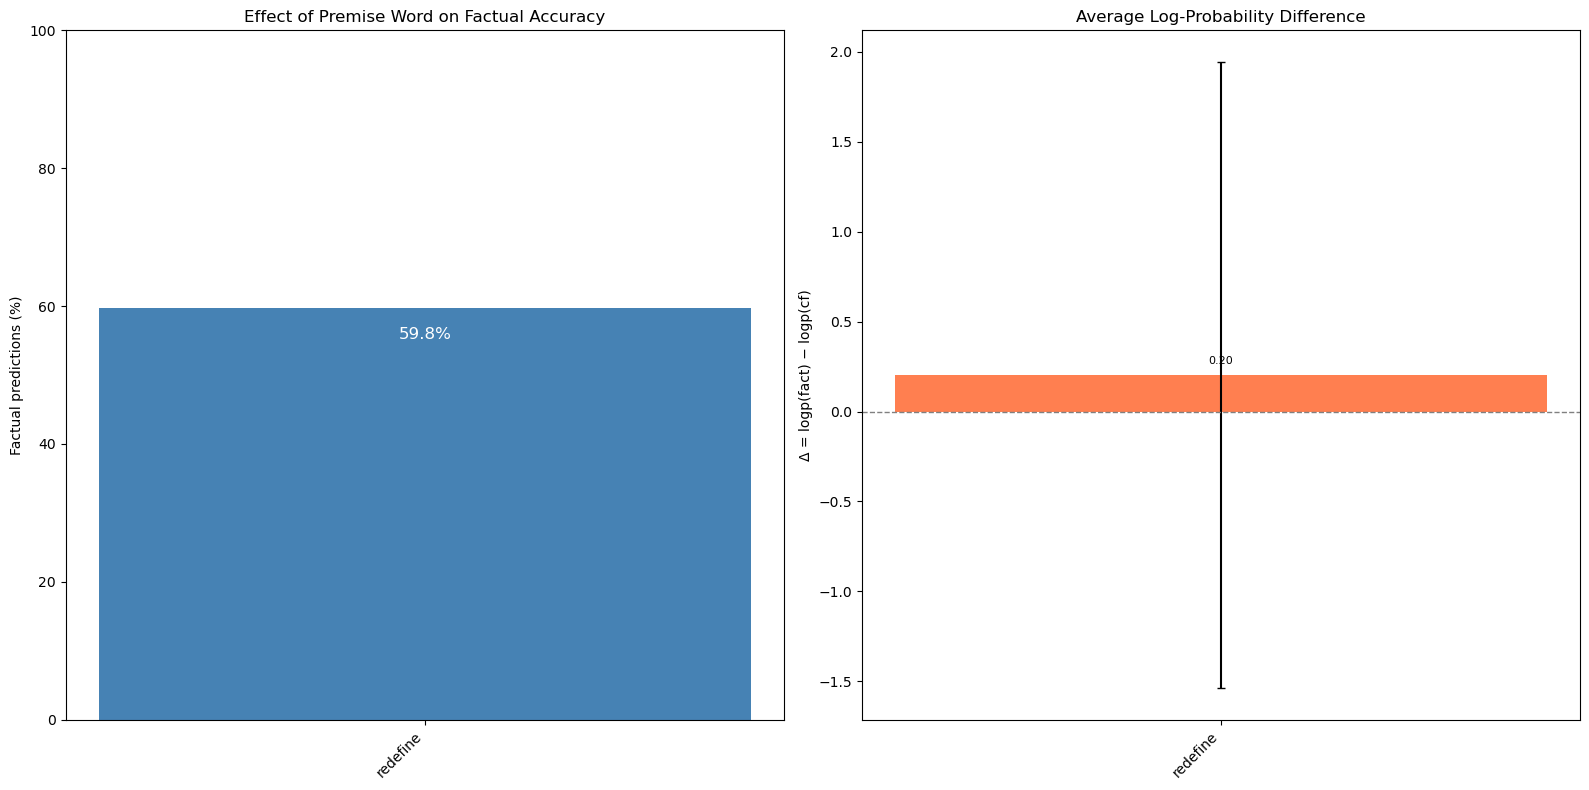

Plot saved as 'premise_word_effect.png'


In [5]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine',
        
        # Verification:
        # 'verify', 'fact check',
        
        # Hypothetical:
        # 'suppose', 'imagine',
        
        # Neutral:
        # 'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"Answer using your own factual knowledge. Do NOT assume the text below is correct.\n"
                    f"Text: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with GPT-2 Medium
    analyzer = PremiseWordAnalyzer(
        dataset_path='./gpt2_with_questions_merged-filtered_factual_987.json',
        model_name='gpt2-medium',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 7. Both Allowed (Natural Competition)**
## Text: "{CF}" Question: {Q} Answer:

Loading model 'gpt2-medium' on cuda...
Model loaded.

Loaded 987 items.

Running experiment...


Processing items: 100%|██████████| 987/987 [00:28<00:00, 35.00it/s]



EFFECT OF PREMISE WORDS
 Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)      Δ  Δ Std
redefine    987   75.7852 24.2148     -1.6415   -2.6230 0.9815 1.7739

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 75.79%, Avg CounterFact: 24.21%, Average Log-Fact: -1.6415, Average Log-CFact: -2.6230, Avg Δ: 0.9815

 Results saved to 'premise_word_results.csv'


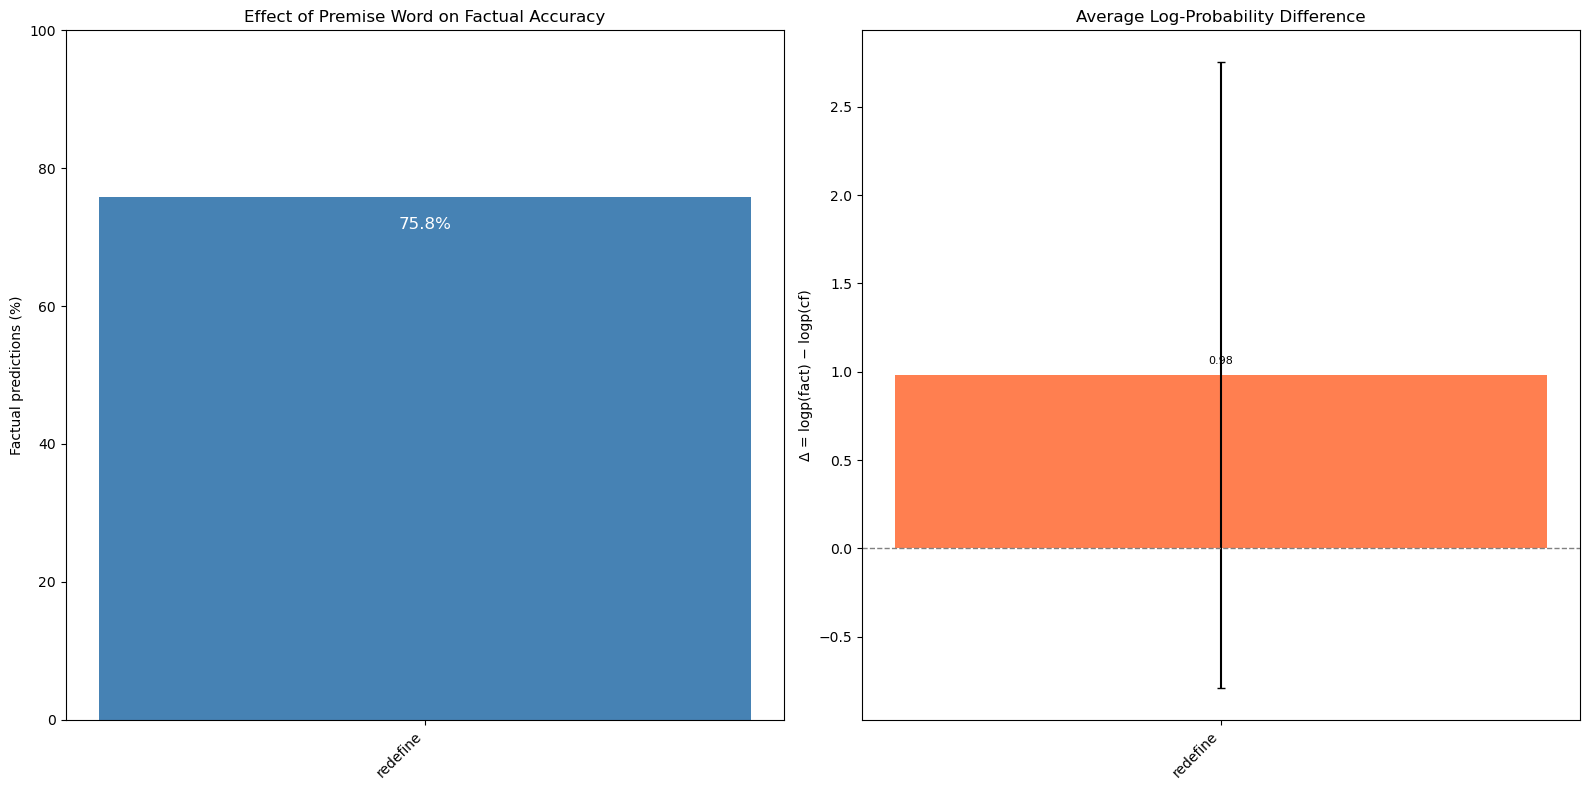

Plot saved as 'premise_word_effect.png'


In [4]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine',
        
        # Verification:
        # 'verify', 'fact check',
        
        # Hypothetical:
        # 'suppose', 'imagine',
        
        # Neutral:
        # 'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    # f"Answer using your own factual knowledge. Do NOT assume the text below is correct.\n"
                    f"Text: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with GPT-2 Medium
    analyzer = PremiseWordAnalyzer(
        dataset_path='./gpt2_with_questions_merged-filtered_factual_987.json',
        model_name='gpt2-medium',
        max_samples=1000
    )
    analyzer.run()